In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv("C:/Users/bonda/OneDrive/Desktop/DATA SCIENCE/Zomato data.csv")

In [9]:
print(df.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [13]:
def remove(value):
	value=str(value).split('/')
	value=value[0];
	return float(value)

df['rate']=df['rate'].apply(remove)
print(df.head())


                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0, 0.5, 'COUNT')

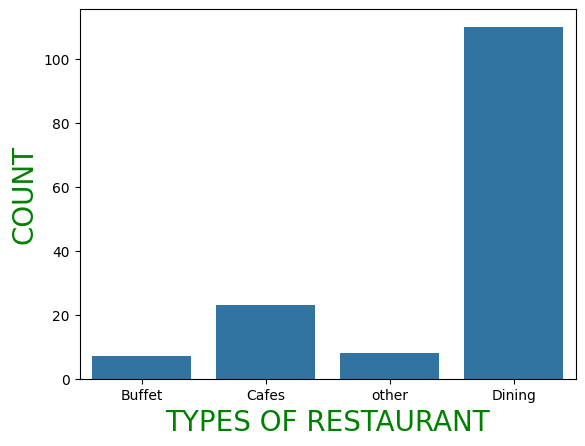

In [30]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("TYPES OF RESTAURANT", c="green", size=20)
plt.ylabel("COUNT", c="green", size=20)

Text(0.5, 0, 'Type of orders')

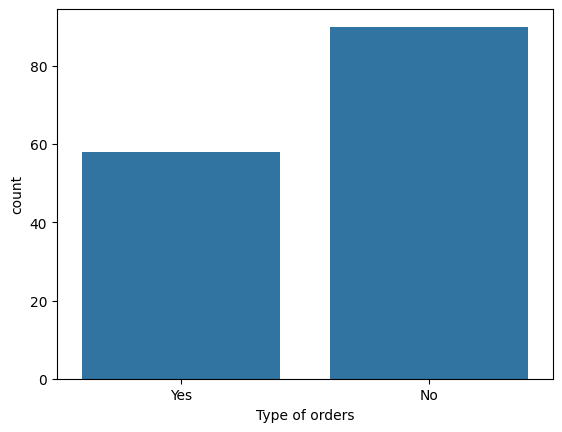

In [18]:
sns.countplot(x=df['online_order'])
plt.xlabel("Type of orders")


Text(0, 0.5, 'Votes')

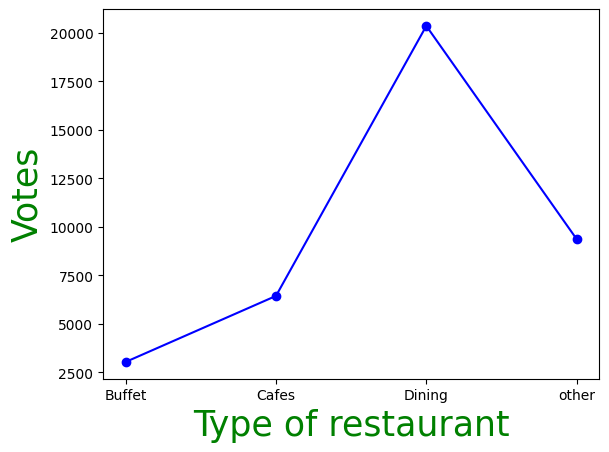

In [21]:
gd = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': gd})
plt.plot(result, c="blue", marker="o")
plt.xlabel("Type of restaurant", c="green", size=25)
plt.ylabel("Votes", c="green", size=25)


In [22]:
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes'] == max_votes, 'name']

print("Restaurant(s) with the maximum votes:")
print(restaurant_with_max_votes)


Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


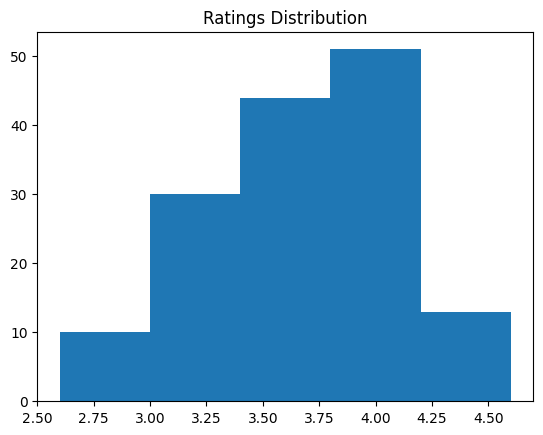

In [24]:
plt.hist(df['rate'],bins=5)
plt.title("Ratings Distribution")
plt.show()


In [33]:
couple_data=df['approx_cost(for two people)']


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

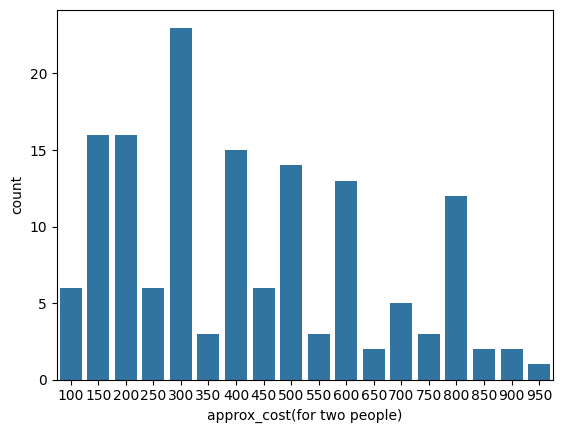

In [34]:
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

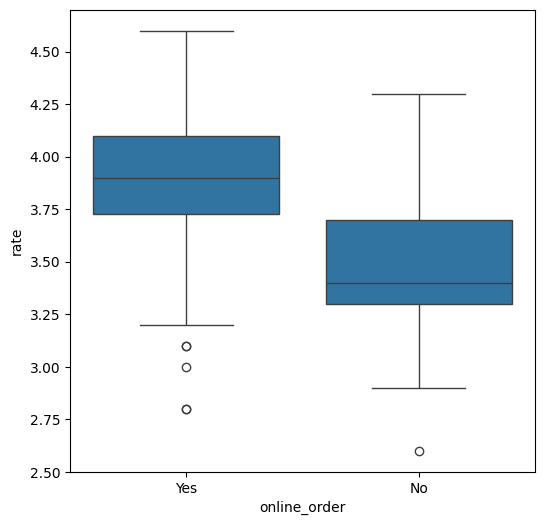

In [35]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)


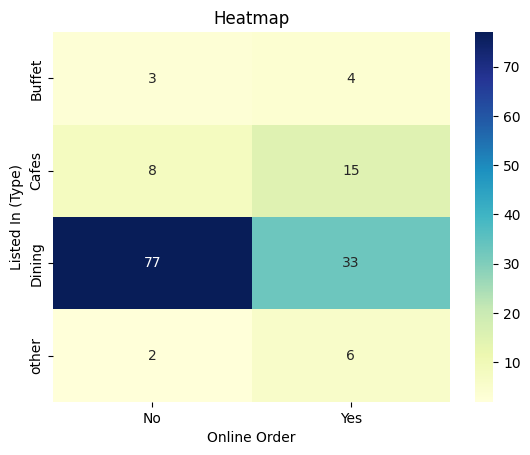

In [36]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")
plt.show()
